<a href="https://colab.research.google.com/github/zohrehasadi00/automatic_image_analysis/blob/main/notebooks/Classical_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fundamental setup

In [1]:
# import collection

import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import cv2

from scipy.sparse import find

In [2]:
#set seed for reproducibility
random_state = 42
torch.manual_seed(42)
np.random.seed(42)


In [3]:
# connect Drive for data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#path to image data
data_raw =[
    '/content/drive/MyDrive/AIA_SkinLesion_Projekt/data/raw/HAM10000_images_part_1',
    '/content/drive/MyDrive/AIA_SkinLesion_Projekt/data/raw/HAM10000_images_part_2'
    ]

# load metadata
csv_path = '/content/drive/MyDrive/AIA_SkinLesion_Projekt/HAM10000_metadata_converted.csv'
df_metadata = pd.read_csv(csv_path)

#load splits
csv_train = '/content/drive/MyDrive/AIA_SkinLesion_Projekt/splits/train.csv'
df_train = pd.read_csv(csv_train)

csv_test = '/content/drive/MyDrive/AIA_SkinLesion_Projekt/splits/test.csv'
df_test = pd.read_csv(csv_test)

csv_val = '/content/drive/MyDrive/AIA_SkinLesion_Projekt/splits/val.csv'
df_val = pd.read_csv(csv_val)

# Data preprocessing for classical pipeline

In [5]:
# define image tranformations for train and test/validation set
train_transforms_classical = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

test_transforms_classical = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

## function for searching images from drive
def find_image_path(img_id, directories):
    img_name = img_id + '.jpg'
    for directory in directories:
        path = os.path.join(directory, img_name)
        if os.path.exists(path):
            return path
    return None

# Dataset class
class SkinDataset(Dataset):
    def __init__(self, dataframe, img_dirs, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dirs = img_dirs
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_id = self.data.loc[idx, 'image_id']
        img_name = img_id + '.jpg'
        img_path = None

        # search in both folders (part 1&2) for the image
        img_path = find_image_path(img_id, self.img_dirs)

        if img_path is None:
            raise FileNotFoundError(f"Image {img_name} not found!")

        image = Image.open(img_path).convert('RGB')
        label = self.data.loc[idx, 'label']

        if self.transform:
            image = self.transform(image)

        # PyTorch expects labels as Float for binary loss (BCEWithLogitsLoss)
        return image, torch.tensor(label, dtype=torch.float32), img_id



# create data sets
train_dataset = SkinDataset(df_train, data_raw, transform=train_transforms_classical)
val_dataset = SkinDataset(df_val, data_raw, transform=test_transforms_classical)
test_dataset = SkinDataset(df_test, data_raw, transform=test_transforms_classical)

In [24]:
## convert RGB to HSV
def tensor_to_hsv(tensor):
    # Tensor (3, H, W) → NumPy (H, W, 3) in RGB
    img_np = tensor.numpy().transpose(1, 2, 0)
    img_uint8 = (img_np * 255).astype(np.uint8)

    # RGB → HSV
    img_hsv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HSV)
    return img_hsv  # shape: (H, W, 3), values: H[0-179], S[0-255], V[0-255]

def compute_hsv_histogram(img_hsv, bins=32):
    hist_h = cv2.calcHist([img_hsv], [0], None, [bins], [0, 180])
    hist_s = cv2.calcHist([img_hsv], [1], None, [bins], [0, 256])
    hist_v = cv2.calcHist([img_hsv], [2], None, [bins], [0, 256])

    # normalize and flatten -> one feature-vector per image
    hist = np.concatenate([hist_h, hist_s, hist_v], axis=0).flatten()
    return hist / hist.sum()

## function for plotting a HSV-histogram from a single image
def plot_hsv_histogram(hist, bins=32):

    #as compute_hsv_histograms return an array with shape (96,) this must be split into 3 channels
    hist_h = hist[:bins]
    hist_s = hist[bins:bins*2]
    hist_v = hist[bins*2:]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, h, name, color in zip(axes,
                                   [hist_h, hist_s, hist_v],
                                   ['Hue', 'Saturation', 'Value'],
                                   ['red', 'blue', 'gray']):
        ax.bar(range(bins), h, color=color, alpha=0.7)
        ax.set_title(name)
        ax.set_xlabel('bin')
        ax.set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()




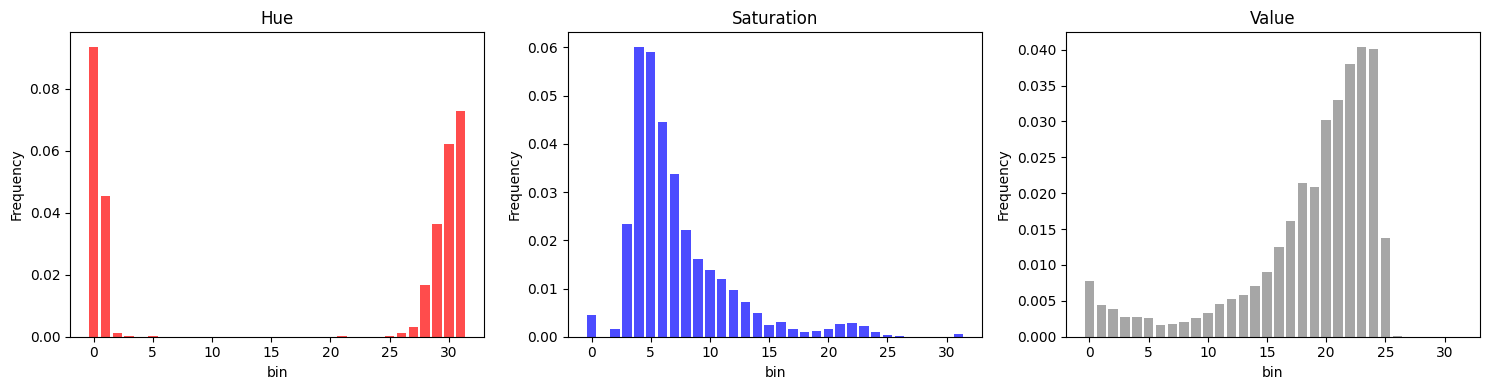

In [23]:
#example histogram

image, label, img_id = train_dataset[42]
img_hsv = tensor_to_hsv(image)
hist = compute_hsv_histogram(img_hsv)

plot_hsv_histogram(hist)


In [ ]:
#compute all histograms
all_histograms = []
all_labels = []

#calculate histogram for each image from training data
for idx in range(len(train_dataset)):
    if idx%1000 == 0: print(idx)
    image, label, img_id = train_dataset[idx]
    img_hsv = tensor_to_hsv(image)
    hist = compute_hsv_histogram(img_hsv)
    all_histograms.append(hist)
    all_labels.append(label.item())

all_histograms = np.array(all_histograms)
all_labels = np.array(all_labels)